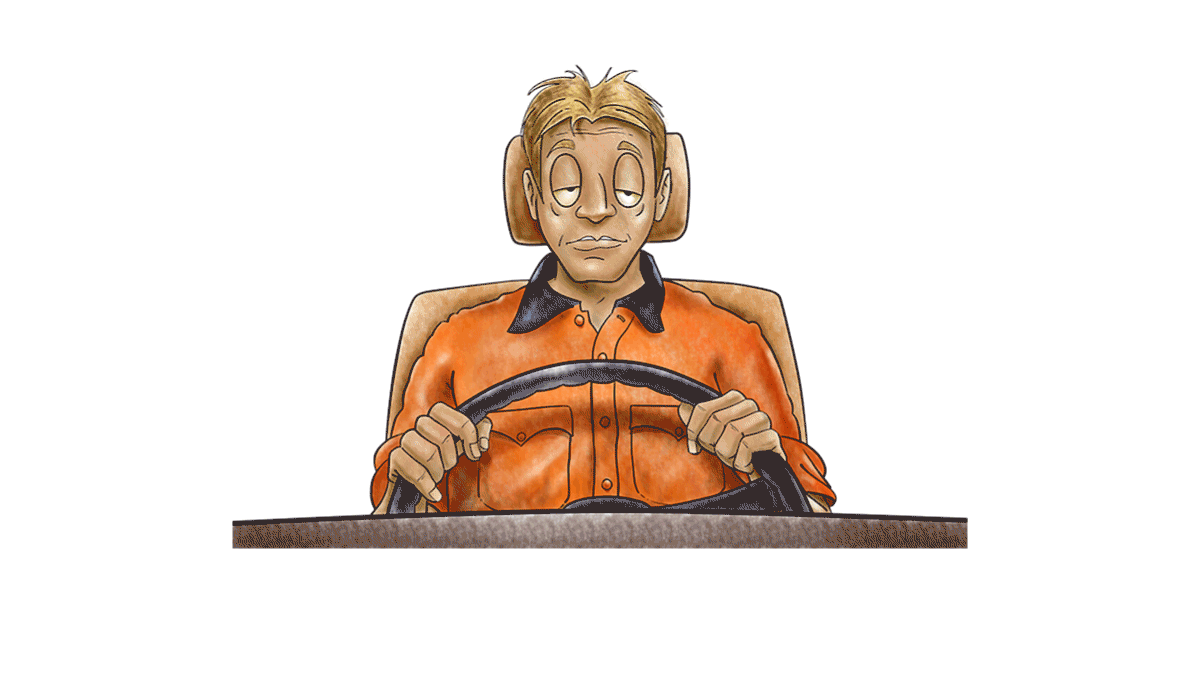

## Driver drowsiness detection is a car safety technology which helps prevent accidents caused by the driver getting drowsy. Various studies have suggested that around 20% of all road accidents are fatigue-related, up to 50% on certain roads.

In [75]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import cv2

In [76]:
# file_path = './train'
# opencv_path = '.'

file_path = 'D:/Github/ML_Final_Data/data'
opencv_path = 'D:/Github/ML_Final_Data/opencv-master/data/haarcascades_cuda'

# labels

In [77]:
# labels = os.listdir("./train")
labels = os.listdir(file_path)

In [78]:
labels

['Closed', 'no_yawn', 'Open', 'yawn']

# visualize random 1 image

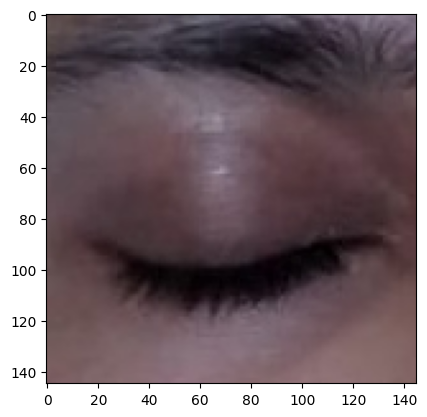

In [79]:
import matplotlib.pyplot as plt
# plt.imshow(plt.imread("./train/Closed/_0.jpg"))
plt.imshow(plt.imread(file_path + "/Closed/_0.jpg"))

# image array

In [80]:
a = plt.imread(file_path + "/yawn/10.jpg")

# image shape

In [81]:
a.shape

(480, 640, 3)

# visualize yawn image. 
# Here background is unnecessary. we need only face image array

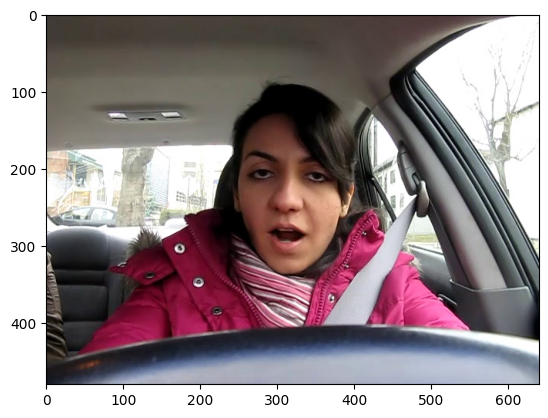

In [82]:
plt.imshow(plt.imread(file_path + "/yawn/10.jpg"))

# for yawn and not_yawn. Take only face

In [83]:
def face_for_yawn(imgsize=145, direc=file_path, face_cas_path=opencv_path + "/haarcascade_frontalface_default.xml"):
    yaw_no = []
    IMG_SIZE = imgsize
    categories = ["yawn", "no_yawn"]
    for category in categories:
        path_link = os.path.join(direc, category)
        class_num1 = categories.index(category)
        print(class_num1)
        for image in os.listdir(path_link):
            image_array = cv2.imread(os.path.join(path_link, image), cv2.IMREAD_COLOR)
            face_cascade = cv2.CascadeClassifier(face_cas_path)
            faces = face_cascade.detectMultiScale(image_array, 1.3, 5)
            for (x, y, w, h) in faces:
                img = cv2.rectangle(image_array, (x, y), (x+w, y+h), (0, 255, 0), 2)
                roi_color = img[y:y+h, x:x+w]
                resized_array = cv2.resize(roi_color, (IMG_SIZE, IMG_SIZE))
                yaw_no.append([resized_array, class_num1])
    return yaw_no
    
# yawn_no_yawn = face_for_yawn()

# for closed and open eye

In [84]:
def get_data(imgsize=145, dir_path=file_path, face_cas=opencv_path + "/haarcascade_frontalface_default.xml", eye_cas=opencv_path + "/haarcascade.xml"):
    labels = ['Closed', 'Open']
    IMG_SIZE = imgsize
    data = []
    for label in labels:
        path = os.path.join(dir_path, label)
        class_num = labels.index(label)
        class_num +=2
        print(class_num)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                data.append([resized_array, class_num])
            except Exception as e:
                print(e)
    return data

In [85]:
# data_train = get_data()

In [125]:
from os.path import exists
from urllib.request import urlretrieve
prototxt = "deploy.prototxt"
caffemodel = "res10_300x300_ssd_iter_140000.caffemodel"

if not exists(prototxt) or not exists(caffemodel):
    urlretrieve(f"https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/{prototxt}",
                prototxt)
    urlretrieve(
        f"https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/{caffemodel}",
        caffemodel)

# extend data and convert array

In [86]:
def append_data(imgsize):
#     total_data = []
    yaw_no = face_for_yawn(imgsize = imgsize)
    # data = get_data()
    # yaw_no.extend(data)
    return np.array(yaw_no, dtype=object)

def append_data_eye(imgsize):
#     total_data = []
    # yaw_no = face_for_yawn()
    data = get_data(imgsize = imgsize)
    # yaw_no.extend(data)
    return np.array(data, dtype=object)

# new variable to store

In [87]:
img_size = 145
new_data = append_data(img_size)
eye_data = append_data_eye(img_size)

0
1
2
3


# separate label and features

In [88]:
X = []
y = []
for feature, label in new_data:
    X.append(feature)
    y.append(label)

X_eye = []
y_eye = []
for feature, label in eye_data:
    X_eye.append(feature)
    y_eye.append(label)

print(len(X_eye))
print(len(y_eye))

1452
1452


# reshape the array

In [89]:
X = np.array(X)
X = X.reshape(-1, img_size, img_size, 3)

X_eye = np.array(X_eye)
print(len(X_eye))

X_eye = X_eye.reshape(-1, img_size, img_size, 3)

print(len(X_eye))

1452
1452


# LabelBinarizer

In [90]:
from sklearn.preprocessing import LabelBinarizer
label_bin = LabelBinarizer()

y_lb = []
for i in y:
    if (i == 0): y_lb.append([1, 0])
    else: y_lb.append([0, 1])

y_eye_lb = []
for i in y_eye:
    if (i == 2): y_eye_lb.append([1, 0])
    else: y_eye_lb.append([0, 1])

# label array

In [91]:
y_lb = np.array(y_lb)
y_eye_lb = np.array(y_eye_lb)

# train test split

In [92]:
print(len(X_eye))
print(len(y_eye_lb))

1452
1452


In [93]:
from sklearn.model_selection import train_test_split
seed = 42
test_size = 0.30
X_train, X_test, y_train, y_test = train_test_split(X, y_lb, random_state=seed, test_size=test_size)
X_train_eye, X_test_eye, y_train_eye, y_test_eye = train_test_split(X_eye, y_eye_lb, random_state=seed, test_size=test_size)

# length of X_test

In [94]:
print(len(X_test))
print(len(X_test_eye))

142
436


# Not necessary, only use to matching with my pc version

In [95]:
# !pip install tensorflow==2.3.1
# !pip install keras==2.4.3

# import some dependencies

In [96]:
import tensorflow as tf
import keras
print(tf.version)

<module 'tensorflow._api.v2.version' from 'c:\\ProgramData\\Anaconda3\\envs\\python3_8_env\\lib\\site-packages\\tensorflow\\_api\\v2\\version\\__init__.py'>


In [97]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Conv2D, MaxPooling2D, Dropout, AveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

# tensorflow version

In [98]:
tf.__version__

'2.11.0'

# keras version

In [99]:
import keras
keras.__version__

'2.11.0'

# Data Augmentation

In [100]:
_train_generator = ImageDataGenerator(rescale=1/255, zoom_range=0.2,
                                      horizontal_flip=True, rotation_range=30)
train_generator = _train_generator.flow(np.array(X_train), y_train, shuffle=False)

_test_generator = ImageDataGenerator(rescale=1/255)

train_generator = _train_generator.flow(np.array(X_train), y_train, shuffle=False)
test_generator = _test_generator.flow(np.array(X_test), y_test, shuffle=False)

train_generator_eye = _train_generator.flow(np.array(X_train_eye), y_train_eye, shuffle=False)
test_generator_eye = _test_generator.flow(np.array(X_test_eye), y_test_eye, shuffle=False)

# model

In [101]:
# model = Sequential()

# model.add(Conv2D(64, (3, 3), activation="relu", input_shape=X_train.shape[1:]))
# model.add(MaxPooling2D(2, 2))

# model.add(Conv2D(32, (3, 3), activation="relu"))
# model.add(MaxPooling2D(2, 2))

# model.add(Flatten())
# model.add(Dropout(0.5))

# model.add(Dense(64, activation="relu"))
# model.add(Dropout(0.5))
# model.add(Dense(16, activation="relu"))
# model.add(Dense(2, activation="softmax"))

# model.compile(loss="categorical_crossentropy", metrics=["accuracy"], optimizer="adam")

# model.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_25 (Conv2D)          (None, 143, 143, 64)      1792      
                                                                 
 max_pooling2d_19 (MaxPoolin  (None, 71, 71, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_26 (Conv2D)          (None, 69, 69, 32)        18464     
                                                                 
 max_pooling2d_20 (MaxPoolin  (None, 34, 34, 32)       0         
 g2D)                                                            
                                                                 
 flatten_9 (Flatten)         (None, 36992)             0         
                                                                 
 dropout_16 (Dropout)        (None, 36992)           

In [102]:
X_train.shape

(331, 145, 145, 3)

In [111]:
# LeNet-5 87% ~ 90%
model = Sequential()

model.add(Conv2D(6, (5, 5), activation="relu", input_shape=X_train.shape[1:]))
model.add(AveragePooling2D())
model.add(Conv2D(16, (5, 5), activation="relu"))
model.add(AveragePooling2D())
model.add(Flatten())
model.add(Dense(120, activation="relu"))
model.add(Dropout(0.25))
model.add(Dense(84, activation="relu"))
model.add(Dropout(0.25))
model.add(Dense(2, activation="softmax"))

model.compile(loss="categorical_crossentropy", metrics=["accuracy"], optimizer="adam")

model.summary()

Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_35 (Conv2D)          (None, 141, 141, 6)       456       
                                                                 
 average_pooling2d_8 (Averag  (None, 70, 70, 6)        0         
 ePooling2D)                                                     
                                                                 
 conv2d_36 (Conv2D)          (None, 66, 66, 16)        2416      
                                                                 
 average_pooling2d_9 (Averag  (None, 33, 33, 16)       0         
 ePooling2D)                                                     
                                                                 
 flatten_14 (Flatten)        (None, 17424)             0         
                                                                 
 dense_38 (Dense)            (None, 120)             

In [108]:
model_eye = Sequential()

model_eye.add(Conv2D(64, (3, 3), activation="relu", input_shape=X_train.shape[1:]))
model_eye.add(MaxPooling2D(2, 2))

model_eye.add(Conv2D(32, (3, 3), activation="relu"))
model_eye.add(MaxPooling2D(2, 2))

model_eye.add(Flatten())
model_eye.add(Dropout(0.5))

model_eye.add(Dense(64, activation="relu"))
model_eye.add(Dropout(0.5))
model_eye.add(Dense(16, activation="relu"))
model_eye.add(Dense(2, activation="softmax"))

model_eye.compile(loss="categorical_crossentropy", metrics=["accuracy"], optimizer="adam")

model_eye.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_31 (Conv2D)          (None, 143, 143, 64)      1792      
                                                                 
 max_pooling2d_21 (MaxPoolin  (None, 71, 71, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_32 (Conv2D)          (None, 69, 69, 32)        18464     
                                                                 
 max_pooling2d_22 (MaxPoolin  (None, 34, 34, 32)       0         
 g2D)                                                            
                                                                 
 flatten_12 (Flatten)        (None, 36992)             0         
                                                                 
 dropout_20 (Dropout)        (None, 36992)           

In [118]:
history = model.fit(train_generator, epochs=30, validation_data=test_generator, shuffle=True, validation_steps=len(test_generator))

Epoch 1/30
11/11 [==============================] - 4s 257ms/step - loss: 0.7388 - accuracy: 0.4320 - val_loss: 0.6929 - val_accuracy: 0.4789
Epoch 2/30
11/11 [==============================] - 3s 234ms/step - loss: 0.6941 - accuracy: 0.5166 - val_loss: 0.6916 - val_accuracy: 0.7394
Epoch 3/30
11/11 [==============================] - 3s 243ms/step - loss: 0.6891 - accuracy: 0.5227 - val_loss: 0.6833 - val_accuracy: 0.5211
Epoch 4/30
11/11 [==============================] - 3s 236ms/step - loss: 0.6619 - accuracy: 0.5196 - val_loss: 0.6107 - val_accuracy: 0.5352
Epoch 5/30
11/11 [==============================] - 3s 237ms/step - loss: 0.5853 - accuracy: 0.5831 - val_loss: 0.5421 - val_accuracy: 0.7676
Epoch 6/30
11/11 [==============================] - 3s 234ms/step - loss: 0.5040 - accuracy: 0.7311 - val_loss: 0.4686 - val_accuracy: 0.8028
Epoch 7/30
11/11 [==============================] - 3s 238ms/step - loss: 0.4784 - accuracy: 0.8036 - val_loss: 0.4295 - val_accuracy: 0.8451
Epoch 

In [112]:
history_eye = model_eye.fit(train_generator_eye, epochs=10, validation_data=test_generator_eye, shuffle=True, validation_steps=len(test_generator_eye))

Epoch 1/10
32/32 [==============================] - 18s 545ms/step - loss: 0.5807 - accuracy: 0.6998 - val_loss: 0.3529 - val_accuracy: 0.8326
Epoch 2/10
32/32 [==============================] - 18s 559ms/step - loss: 0.3292 - accuracy: 0.8750 - val_loss: 0.2438 - val_accuracy: 0.8853
Epoch 3/10
32/32 [==============================] - 19s 595ms/step - loss: 0.2409 - accuracy: 0.9094 - val_loss: 0.1871 - val_accuracy: 0.9312
Epoch 4/10
32/32 [==============================] - 19s 598ms/step - loss: 0.2134 - accuracy: 0.9291 - val_loss: 0.1805 - val_accuracy: 0.9450
Epoch 5/10
32/32 [==============================] - 19s 596ms/step - loss: 0.1862 - accuracy: 0.9350 - val_loss: 0.1777 - val_accuracy: 0.9312
Epoch 6/10
32/32 [==============================] - 19s 576ms/step - loss: 0.1747 - accuracy: 0.9321 - val_loss: 0.1343 - val_accuracy: 0.9495
Epoch 7/10
32/32 [==============================] - 19s 592ms/step - loss: 0.1798 - accuracy: 0.9350 - val_loss: 0.1023 - val_accuracy: 0.9656

# history

In [32]:
# accuracy = history.history['accuracy']
# val_accuracy = history.history['val_accuracy']
# loss = history.history['loss']
# val_loss = history.history['val_loss']
# epochs = range(len(accuracy))

# plt.plot(epochs, accuracy, "b", label="trainning accuracy")
# plt.plot(epochs, val_accuracy, "r", label="validation accuracy")
# plt.legend()
# plt.show()

# plt.plot(epochs, loss, "b", label="trainning loss")
# plt.plot(epochs, val_loss, "r", label="validation loss")
# plt.legend()
# plt.show()

In [33]:
# accuracy = history_eye.history['accuracy']
# val_accuracy = history_eye.history['val_accuracy']
# loss = history_eye.history['loss']
# val_loss = history_eye.history['val_loss']
# epochs = range(len(accuracy))

# plt.plot(epochs, accuracy, "b", label="trainning accuracy")
# plt.plot(epochs, val_accuracy, "r", label="validation accuracy")
# plt.legend()
# plt.show()

# plt.plot(epochs, loss, "b", label="trainning loss")
# plt.plot(epochs, val_loss, "r", label="validation loss")
# plt.legend()
# plt.show()

# save model

In [119]:
model.save("drowiness_new6.h5")
model_eye.save("drowiness_new6_eye.h5")

In [120]:
model.save("drowiness_new6.model")
model_eye.save("drowiness_new6_eye.model")

INFO:tensorflow:Assets written to: drowiness_new6.model\assets


INFO:tensorflow:Assets written to: drowiness_new6.model\assets


INFO:tensorflow:Assets written to: drowiness_new6_eye.model\assets


INFO:tensorflow:Assets written to: drowiness_new6_eye.model\assets


# Prediction

In [36]:
#prediction = model.predict_classes(X_test)
# predict_x=model.predict(X_test) 
# classes_x=np.argmax(predict_x,axis=1)

In [37]:
# classes_x

In [38]:
# predict_x_eye=model_eye.predict(X_test_eye) 
# classes_x_eye=np.argmax(predict_x_eye,axis=1)
# print(classes_x_eye)

# classification report

In [39]:
labels_new = ["yawn", "no_yawn", "Closed", "Open"]

In [40]:
# from sklearn.metrics import classification_report
# print(classification_report(np.argmax(y_test, axis=1), classes_x, target_names=labels_new))

In [41]:
# print(classification_report(np.argmax(y_test_eye, axis=1), classes_x_eye, target_names=labels_new))
# !!!!!!!!!!!!!!!

# predicting function

In [1]:
import tensorflow as tf
labels_new = ["yawn", "no_yawn", "Closed", "Open"]
IMG_SIZE = 145
def prepare(filepath, face_cas="../input/prediction-images/haarcascade_frontalface_default.xml"):
    img_array = cv2.imread(filepath, cv2.IMREAD_COLOR)
    img_array = img_array / 255
    resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
    return resized_array.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

model = tf.keras.models.load_model("./drowiness_new6.h5")

Camera

In [2]:
labels_new = ["yawn", "no_yawn", "Closed", "Open"]
IMG_SIZE = 145
def prepare_camera(img_array):
    img_array = img_array / 255
    resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
    return resized_array.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

In [44]:
# import tensorflow as tf
# # model = tf.keras.models.load_model("./drowiness_new6.h5")
# import cv2
# import numpy as np
# cap = cv2.VideoCapture(0)
# face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
# if not cap.isOpened():
#     print("Cannot open camera")
#     exit()
# while True:
#     ret, frame = cap.read()
#     if not ret:
#         print("Cannot receive frame")
#         break
#     frame = cv2.resize(frame,(540,320))              # 縮小尺寸，避免尺寸過大導致效能不好
#     gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)   # 將鏡頭影像轉換成灰階
#     faces = face_cascade.detectMultiScale(gray)      # 偵測人臉
    
#     for (x, y, w, h) in faces:
#         cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)   # 標記人臉
#         prediction = model.predict(prepare_camera(frame))
#         prediction_eye = model_eye.predict(prepare_camera(frame))
#         # prediction = model.predict(prepare("./train/yawn/18.jpg"))
#         label_out = str(np.argmax(prediction))
#         cv2.putText(frame, label_out, (x-10, y-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 1, cv2.LINE_AA)
#     cv2.imshow('oxxostudio', frame)
#     if cv2.waitKey(1) == ord('q'):
#         break
# cap.release()
# cv2.destroyAllWindows()

In [3]:
pred_seq = []
max_seq = 5
closed_seq = 3
def closed_label(prediction):
    global pred_seq
    in_seq = 1 if prediction == 0 else 0
    if len(pred_seq) < max_seq:
        pred_seq.append(in_seq)
    else:
        pred_seq = pred_seq[-max_seq+1:]
        pred_seq.append(in_seq)
    if sum(pred_seq) >= closed_seq:
        return 0 # closed
    else:
        return 1 # open

In [25]:
drowsiness_seq = []
max_drowsiness_num = 10
drowsiness_num = 5
sleepy_seq = []
sleepy_max = 120
sleepy_num = 80
last_sleep_max = 20
last_sleep_num = 7
def drowsiness_text(yawn_pred, eye_pred):
    global drowsiness_seq, sleepy_seq
    if yawn_pred == 1 and eye_pred == 1:
        level = 0
    elif yawn_pred + eye_pred == 1:
        level = 1
    else:
        level = 2

    if len(sleepy_seq) < sleepy_max:
        sleepy_seq.append(1 if eye_pred == 0 else 0)
    else:
        sleepy_seq = sleepy_seq[-sleepy_max+1:]
        sleepy_seq.append(1 if eye_pred == 0 else 0)

    if len(drowsiness_seq) < max_drowsiness_num:
        drowsiness_seq.append(1 if level == 2 else 0)
    else:
        drowsiness_seq = drowsiness_seq[-max_drowsiness_num+1:]
        drowsiness_seq.append(1 if level == 2 else 0)
    
    if sum(drowsiness_seq) >= drowsiness_num:
        return 'Danger'
    elif level >= 1 and sum(sleepy_seq) >= sleepy_num and sum(sleepy_seq[-last_sleep_max:]) >= last_sleep_num:
        return 'Danger'
    elif level >= 1:
        return 'Warning'
    elif level == 0:
        return 'Sober'
    

In [27]:
import tensorflow as tf
import cv2
import numpy as np
import os


model = tf.keras.models.load_model("./drowiness_new6.h5")   #load your model
model_eye = tf.keras.models.load_model("./drowiness_new6_eye.h5")   #load your model

face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_alt2.xml")
eye_cascade = cv2.CascadeClassifier("haarcascade_eye.xml")


IMG_SIZE = 145
def prepare_camera(img_array):
    img_array = img_array / 255
    print(img_array.shape)
    resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
    return resized_array.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

def cut_eyes(frame):
    faces = face_cascade.detectMultiScale(gray)
    eyes = eye_cascade.detectMultiScale(gray)
    true_eyes = np.zeros(shape=(0,0))
    for (x, y, w, h) in faces:
        for(a,b,c,d) in eyes:
              if(a > x and a+c < x+w and b>y and b+d < w+h):
                    cv2.rectangle(frame, (a,b), (a+c,b+d),(0,255,0),2)
                    true_eyes = np.append(true_eyes,np.array([a,b,c,d]))
    eye = np.zeros(shape=(int(len(true_eyes)/4),4))
    for i in range(int(len(true_eyes)/4)):
        eye[i] = true_eyes[i*4],true_eyes[i*4+1],true_eyes[i*4+2],true_eyes[i*4+3]
    return eye
# cap = cv2.VideoCapture(0)   # use camera
cap = cv2.VideoCapture('./IMG_9543.MOV')   # use video

if not cap.isOpened():
    print("Cannot open camera")
    exit()
pred_seq = []
drowsiness_seq = []
sleepy_seq = []
while True:
    ret, frame = cap.read()
    if not ret:
        print("Cannot receive frame")
        break
        
    frame = cv2.resize(frame,(540,320))              # 縮小尺寸，避免尺寸過大導致效能不好
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)   # 將鏡頭影像轉換成灰階
    faces = face_cascade.detectMultiScale(gray)      # 偵測人臉
    # print("!!!", faces)
    eyes = cut_eyes(gray)
    if (len(faces) != 0):
        max_faces = np.transpose(faces)
        id = np.argmax(max_faces[2], axis=0)
        (x1, y1, w1, h1) = faces[id]
        crop_face = frame[int(y1):int(y1+h1), int(x1):int(x1+w1)]
        prediction = model.predict(prepare_camera(crop_face))
        crop_eye = None
        pred_eye = -1
        flag = 0
        if (len(eyes) != 0):
            for _x,_y,_w,_h in eyes:
                if (_y < y1 + (h1)/2):
                    flag = 1
                    crop_eye = frame[int(_y):int(_y+_h), int(_x):int(_x+_w)]
                    # cv2.rectangle(frame, (int(_x), int(_y)), (int(_x)+int(_w), int(_y)+int(_h)), (0, 255, 0), 2)   #框出眼睛


            if (flag):
                prediction_eye = model_eye.predict(prepare_camera(crop_eye))
                label_eye = str(np.argmax(prediction_eye))
                pred_eye = closed_label(label_eye)
                # print("eye:", label_eye)
                
            else:
                pred_eye = closed_label(0)
                cv2.putText(frame, str(pred_eye), (x1+20, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 1, cv2.LINE_AA)

            txt = drowsiness_text(np.argmax(prediction), pred_eye)
            
        else:
            pred_eye = closed_label(0)
            txt = drowsiness_text(np.argmax(prediction), pred_eye)
            # cv2.putText(frame, str(pred_eye), (x1+20, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 1, cv2.LINE_AA)
            # cv2.putText(frame, str(2), (x1+20, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 1, cv2.LINE_AA)

        label_out = str(np.argmax(prediction))
        # print("face", label_out)
        if (txt == 'Danger'):
            # os.system('say "Danger."')
            cv2.putText(frame, txt, (x1, y1+h1+30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2, cv2.LINE_AA)
            cv2.putText(frame, str(pred_eye), (x1+20, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 1, cv2.LINE_AA)
            cv2.putText(frame, label_out, (x1-10, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 1, cv2.LINE_AA)
            cv2.rectangle(frame, (x1, y1), (x1+w1, y1+h1), (0, 0, 255), 2)   # 標記人臉
        elif(txt == 'Warning'):
            cv2.putText(frame, txt, (x1, y1+h1+30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 165, 255), 2, cv2.LINE_AA)
            cv2.putText(frame, str(pred_eye), (x1+20, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 165, 255), 1, cv2.LINE_AA)
            cv2.putText(frame, label_out, (x1-10, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 165, 255), 1, cv2.LINE_AA)
            cv2.rectangle(frame, (x1, y1), (x1+w1, y1+h1), (0, 165, 255), 2)
        else:
            cv2.putText(frame, txt, (x1, y1+h1+30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)
            cv2.putText(frame, str(pred_eye), (x1+20, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 1, cv2.LINE_AA)
            cv2.putText(frame, label_out, (x1-10, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 1, cv2.LINE_AA)
            cv2.rectangle(frame, (x1, y1), (x1+w1, y1+h1), (0, 255, 0), 2)

    cv2.imshow('Team13', frame)
    if cv2.waitKey(1) == ord('q'):
        break

KeyboardInterrupt: 

: 

# Prediction 
## 0-yawn, 1-no_yawn, 2-Closed, 3-Open

In [ ]:

IMG_SIZE = 145
def prepare(filepath, face_cas="../input/prediction-images/haarcascade_frontalface_default.xml"):
    img_array = cv2.imread(filepath, cv2.IMREAD_COLOR)
    img_array = img_array / 255
    resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
    return resized_array.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

In [ ]:
# prepare("./train/no_yawn/1068.jpg")
prediction = model.predict([prepare("./train/no_yawn/1067.jpg")])
np.argmax(prediction)

1/1 [==============================] - 0s 67ms/step


1

In [ ]:
prediction = model_eye.predict([prepare("./train/Closed/_101.jpg")])
np.argmax(prediction)

1/1 [==============================] - 0s 61ms/step


0

In [ ]:
prediction = model_eye.predict([prepare("./train/Open/_104.jpg")])
np.argmax(prediction)

1/1 [==============================] - 0s 29ms/step


1

In [ ]:
prediction = model.predict([prepare("./781916.jpg")])
np.argmax(prediction)

1/1 [==============================] - 0s 12ms/step


0

In [ ]:
prediction = model.predict([prepare("./train/yawn/113.jpg")])
np.argmax(prediction)

res = []
for i in range(100):
    if (i == 0): continue
    path = "./train/yawn/"+str(i)+".jpg"
    prediction = model.predict([prepare(path)])
    res.append(np.argmax(prediction))
print(res)

1/1 [==============================] - 0s 13ms/step
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1]


# If you like please upvote